In [6]:
!pip install rasterio 
!pip install rpcm

  Using cached rpcm-1.4.10-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyproj-3.7.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (31 kB)
  Using cached geojson-3.2.0-py3-none-any.whl.metadata (16 kB)
  Using cached srtm4-1.2.5.tar.gz (2.0 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached boto3-1.37.28-py3-none-any.whl.metadata (6.7 kB)
  Using cached botocore-1.37.28-py3-none-any.whl.metadata (5.7 kB)
  Using cached jmespath-1.0.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached s3transfer-0.11.4-py3-none-any.whl.metadata (1.7 kB)
Using cached rpcm-1.4.10-py3-none-any.whl (17 kB)
Using cached geojson-3.2.0-py3-none-any.whl (15 kB)
Using cached pyproj-3.7.1-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (9.5 MB)
Using cached boto3-1.37.28-py3-none-any.whl (139 kB)
Using cached botocore-1.37.28-py3-none-any.whl (13.5 MB)
Using cached jmespath-1

In [10]:
!pip install srtm4
!pip install rpcm

  Using cached srtm4-1.2.5.tar.gz (2.0 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for srtm4 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [123 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build/lib/srtm4
      copying srtm4/__init__.py -> build/lib/srtm4
      copying srtm4/point.py -> build/lib/srtm4
      copying srtm4/download.py -> build/lib/srtm4
      copying srtm4/raster.py -> build/lib/srtm4
      running egg_info
      writing srtm4.egg-info/PKG-INFO
      writing dependency_links to srtm4.egg-info/dependency_links.txt
      writing requirements to srtm4.egg-info/requires.txt
      writing top-level names to srtm4.egg-info/top_level.txt
      reading manifest file 'srtm4.egg-info/SOURCES.txt'
      reading manifest template 'MANIFEST.in'
      writi

In [8]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rpcm.rpc_model import RPCModel

# Replace with your image path
tif_path = 'images/GF2_PMS1__L1A0000564539-MSS1.tif'

# RPC data you provided
rpc_dict = {
    'LINE_OFF': 3645.0,
    'SAMP_OFF': 3654.0,
    'LAT_OFF': 28.317770600224417,
    'LONG_OFF': 115.852824076467883,
    'HEIGHT_OFF': 6.94256614011414,
    'LINE_SCALE': 4224.0,
    'SAMP_SCALE': 4224.0,
    'LAT_SCALE': 0.14419513357149,
    'LONG_SCALE': 0.162540095893945,
    'HEIGHT_SCALE': 2044.0551403841287,
    'LINE_NUM_COEFF': [
        +2.538640063305229E-04, -2.537595451612704E-01, -1.161825035880366E+00,
        +1.136919284886127E-03, +2.018082087828474E-04, -4.191020090974481E-06,
        -1.996783515516497E-05, -7.778407454320550E-04, -9.375452423861647E-04,
        -3.456635617798031E-07, +9.799551475713991E-06, +5.261340403418939E-05,
        +2.403617746398191E-03, +5.509429177412236E-07, +3.992434312289499E-04,
        +7.654619629556023E-03, +2.473578943406718E-06, -2.944166911386489E-07,
        +4.159380818850867E-05, -2.360613414950110E-09
    ],
    'LINE_DEN_COEFF': [
        +1.000000000000000E+00, +6.273176198108709E-05, +5.397421570769308E-04,
        +1.681672522155044E-05, -7.135849778395210E-04, +4.343835618049401E-07,
        -4.110562170716458E-05, -2.184072623537087E-04, -6.781969335910710E-03,
        -2.171086579066779E-06, +1.244231581544366E-07, -7.722821942678410E-07,
        +1.150373666271690E-08, -6.666077006211530E-10, +2.965337978669399E-06,
        +1.908098498473345E-05, +1.665557245717243E-09, +5.036543290857896E-08,
        +3.081144148940918E-07, +1.739753971908810E-11
    ],
    'SAMP_NUM_COEFF': [
        -1.423502567563388E-04, +1.172546784613456E+00, -2.577545517199973E-01,
        -3.921013919876685E-03, -1.274223803108593E-03, +2.814998574621741E-03,
        -6.190261980351406E-04, -1.820723654725182E-04, -1.698101330989039E-05,
        -8.157664500710667E-06, -2.600720975614746E-06, -2.892056560095529E-05,
        +2.772126691505502E-05, +5.280063218522708E-06, +3.423441712938715E-05,
        -1.677765818896600E-05, -1.169575420925041E-06, +4.072179032313793E-06,
        -3.122192829442849E-07, -1.509361654438129E-08
    ],
    'SAMP_DEN_COEFF': [
        +1.000000000000000E+00, -6.701930276028661E-04, +4.211923941048687E-04,
        -1.198671948781810E-03, +1.224662025930339E-05, +2.295247464016031E-06,
        +1.336438090690051E-06, +7.376312087583520E-06, +3.843357204065196E-05,
        -2.971648175752895E-06, -1.147475345269158E-07, +4.655415776135540E-09,
        +6.664980070757186E-08, -1.557185757125713E-08, -1.039857549079506E-07,
        +4.388509515324514E-08, +1.665132140749582E-10, +1.584509734605906E-07,
        -1.185325888656170E-07, -1.385856214105003E-08
    ]
}

# Load image
with rasterio.open(tif_path) as src:
    img = src.read([1, 2, 3])
    height, width = src.height, src.width

# Build RPC model
rpc = RPCModel(rpc_dict)

# Create meshgrid of pixel coords
rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing='ij')
rows_flat = rows.flatten()
cols_flat = cols.flatten()
alt_flat = np.full_like(rows_flat, rpc_dict['HEIGHT_OFF'])

# Convert to lat/lon
lat, lon = rpc.localization(cols_flat, rows_flat, alt_flat)
lat = lat.reshape((height, width))
lon = lon.reshape((height, width))

# Create a simple lat/lon mask
lat_min, lat_max = 28.25, 28.35
lon_min, lon_max = 115.80, 115.90
mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)

# Apply mask to image
masked_img = np.copy(img)
masked_img[:, ~mask] = 0

# Show it
plt.imshow(np.transpose(masked_img, (1, 2, 0)))
plt.title("Masked Image using RPC")
plt.axis('off')
plt.show()


ModuleNotFoundError: No module named 'rpcm'

/home/laptop-pr-31/miniconda3/envs/solar-det/lib/python3.13/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Unique label values: [  0 255]


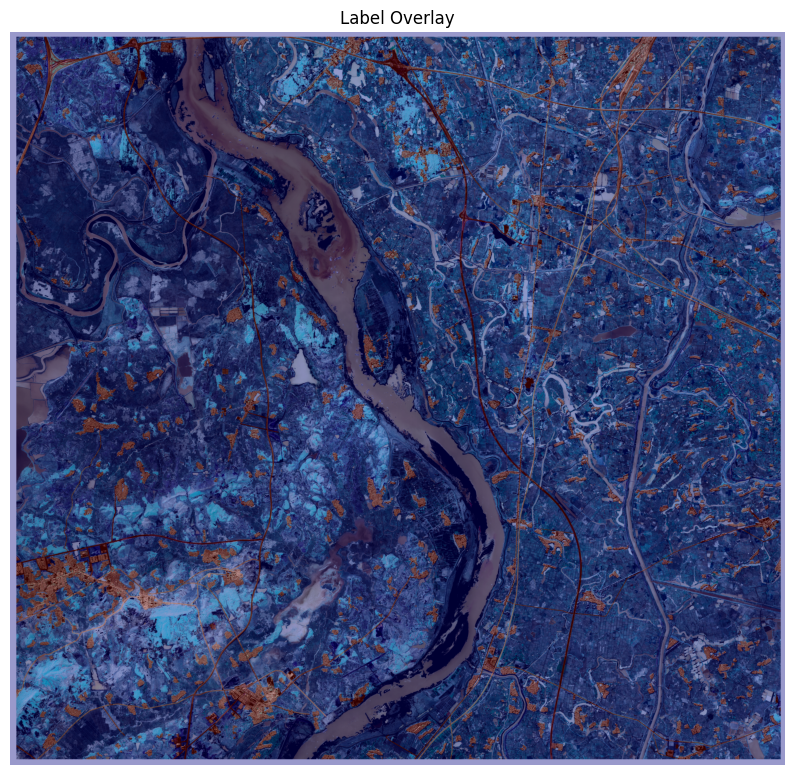

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Load original image
with rasterio.open("images/GF2_PMS1__L1A0000564539-MSS1.tif") as src:
    original = src.read([1, 2, 3])  # Assuming it's RGB

# Load label image
with rasterio.open("images/GF2_PMS1__L1A0000564539-MSS1_5label.tif") as label_src:
    label = label_src.read(1)

# Unique values in label
unique_vals = np.unique(label)
print("Unique label values:", unique_vals)

# Plotting overlay
plt.figure(figsize=(10, 10))
plt.imshow(np.transpose(original, (1, 2, 0)))  # Convert to HxWxC
plt.imshow(label, cmap='jet', alpha=0.4)       # Overlay with transparency
plt.title("Label Overlay")
plt.axis('off')
plt.show()


Unique label values: [ 0  1  3  4  6  7 11 12 13 14 15 16 17 18 21 22 23]


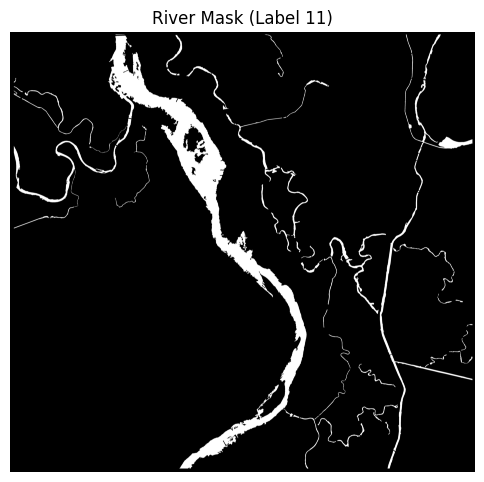

In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load the label image (indexed mask)
label_path = "images/GF2_PMS1__L1A0000564539-MSS1_24label.png"
label_img = Image.open(label_path)
label_array = np.array(label_img)

# Show unique values in the label image
unique_values = np.unique(label_array)
print("Unique label values:", unique_values)

# Create mask for river (label 11)
river_mask = (label_array == 11).astype(np.uint8)

# Display the river mask
plt.figure(figsize=(6, 6))
plt.imshow(river_mask, cmap='gray')
plt.title("River Mask (Label 11)")
plt.axis("off")
plt.show()


In [14]:
import os
from PIL import Image
import numpy as np
import torchvision.transforms as T

# --- Config ---
input_dir = "images/Image__8bit_NirRGB"
output_dir = "images/Image__normalized_resized"
os.makedirs(output_dir, exist_ok=True)

target_size = (512, 512)  # Resize to fit into GPU/memory

# --- Transformation ---
transform = T.Compose([
    T.Resize(target_size, interpolation=Image.BILINEAR),
    T.ToTensor(),  # Converts to [C, H, W] with float values in [0, 1]
])

# --- Loop through images ---
for filename in os.listdir(input_dir):
    if filename.endswith(".tif") or filename.endswith(".png"):
        img_path = os.path.join(input_dir, filename)
        img = Image.open(img_path).convert("RGB")  # Convert from NirRGB to RGB

        img_tensor = transform(img)  # [C, H, W], values in [0, 1]
        img_np = (img_tensor.numpy() * 255).astype(np.uint8)  # Back to 0-255

        # Convert back to Image for saving
        img_resized = Image.fromarray(np.transpose(img_np, (1, 2, 0)))  # [H, W, C]

        # Save as PNG (lossless and smaller size)
        save_path = os.path.join(output_dir, filename.replace(".tif", ".png"))
        img_resized.save(save_path)

        print(f"Saved {save_path}")

Saved images/Image__normalized_resized/GF2_PMS2__L1A0001396037-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001251800-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0001793003-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0000607677-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0001395956-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001367842-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0000708367-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001723991-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0001765574-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0001668483-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS1__L1A0001553848-MSS1.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001787080-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001537637-MSS2.png
Saved images/Image__normalized_resized/GF2_PMS2__L1A0001824765-M

In [15]:
import os
from PIL import Image
import torchvision.transforms as T

# --- Config ---
input_mask_dir = "images/Annotation__index"
output_mask_dir = "images/Annotation__index_resized"
os.makedirs(output_mask_dir, exist_ok=True)

target_size = (512, 512)  # Should match resized image size exactly

# --- Transformation ---
resize = T.Resize(target_size, interpolation=Image.NEAREST)  # NEAREST to preserve label values

# --- Loop through masks ---
for filename in os.listdir(input_mask_dir):
    if filename.endswith(".tif") or filename.endswith(".png"):
        mask_path = os.path.join(input_mask_dir, filename)
        mask = Image.open(mask_path)  # Single-channel index image

        mask_resized = resize(mask)  # Resize
        save_path = os.path.join(output_mask_dir, filename.replace(".tif", ".png"))
        mask_resized.save(save_path)

        print(f"Saved {save_path}")

Saved images/Annotation__index_resized/GF2_PMS1__L1A0001680851-MSS1_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001393716-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001015596-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001886305-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0000658637-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001708261-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001116444-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001746797-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0000788763-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0000658636-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS2__L1A0001465929-MSS2_24label.png
Saved images/Annotation__index_resized/GF2_PMS1__L1A0000708367-MSS1_24label.png
Saved images/Annotation__index_resized/G

[ 0  1  3  4  6  7 11 12 13 14 15 16 17 18 21 22 23]


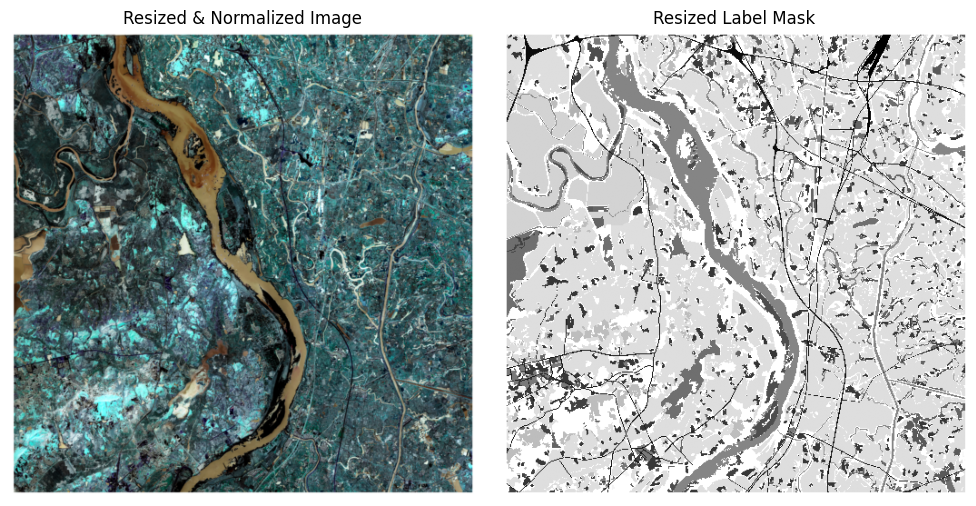

In [20]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Replace with actual file names
image_path = "images/Image__normalized_resized/GF2_PMS1__L1A0000564539-MSS1.png"
mask_path = "images/Annotation__index_resized/GF2_PMS1__L1A0000564539-MSS1_24label.png"

# Load image (should be 3-channel RGB or 4-channel NirRGB)
image = Image.open(image_path)
mask = Image.open(mask_path)

# Convert to numpy for visualization
image_np = np.array(image)
mask_np = np.array(mask)
print(np.unique(mask_np))
# Plot
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image_np)
axs[0].set_title("Resized & Normalized Image")
axs[0].axis("off")

axs[1].imshow(mask_np, cmap='binary')
axs[1].set_title("Resized Label Mask")
axs[1].axis("off")

plt.tight_layout()
plt.show()
